# **Computer Vision H.W. #1**
---
___
# *Student ID and Names: -*

b00094286 ---- Mohamed Abdelrahim Alawadhi

b00097405 ---- Arya Sankhe
___

# Part 1: 4 Marks MCQs

## Question 1:
What is the typical range for pixel values in an image?

- [ ] [0-100]
- [ ] [0-255]
- [ ] [0-1]
- [✔] **Both B and C**

## Question 2:
What does trichromatic theory explain?

- [ ] The perception of sound
- [ ] The perception of light wavelengths
- [✔] **The perception of different colors**
- [ ] The perception of temperature

## Question 3:
What does a 3-dimensional array in a color image represent?

- [ ] Intensity of light
- [✔] **Red, Green, and Blue color intensities**
- [ ] Hue, Saturation, and color intensities
- [ ] Pixel coordinates

## Question 4:
What does the Gray World Assumption in white balance adjustment imply?

- [ ] The scene should have equal levels of brightness.
- [ ] The scene should contain mostly gray objects.
- [✔] **The color channels should have equal mean values.**
- [ ] The lighting should be neutral.


# Part 2: Coding

## Question 1: Convert RGB Image to Grayscale (3 marks)

Write a function that converts a given RGB image to a grayscale image using the weighted sum method.

### Hint:
You need to search for the correct mathematical formula to be applied to the Red, Green, and Blue channels of the image.

### Instructions:
- You need to use the `cat.jpg` image to complete this question.
- After converting the image to grayscale, you need to show your result.
- You’re not allowed to use OpenCV predefined conversion functions to convert it directly.
- Submit the resulted image with your code as `cat_grayscale.jpg`.


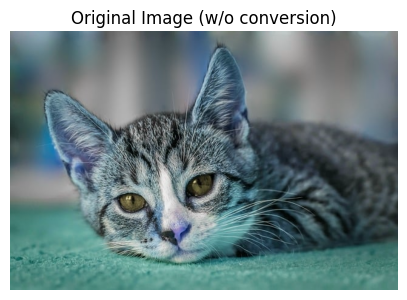

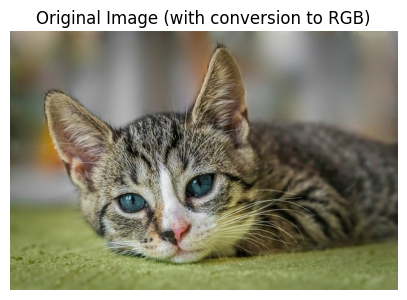

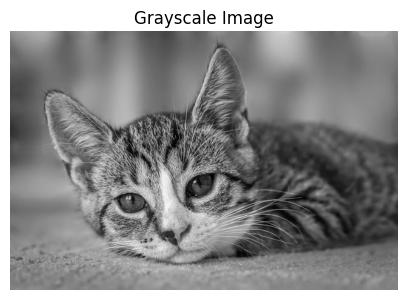

In [ ]:
from matplotlib import pyplot as plt
import cv2 as cv
import sys

# Reading the image and an if statement if the image does not exist, it exits the program
img = cv.imread("/content/cat.jpg")
if img is None:
  sys.exit("Could not read the image.")

# OpenCV reads images with the 3 channels reversed (BGR)
plt.figure(figsize = (5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image (w/o conversion)")
plt.show()

# So, inorder to get the original image, let's convert it back to RGB
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.figure(figsize = (5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image (with conversion to RGB)")
plt.show()

# ==============================================================================

# Now let's convert it to Grayscale with a function (Weighted Sum method) instead of using the OpenCV conversion function
def RGB2Gray(image):
  R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]    # Extracting the channels
  gray = 0.30 * R + 0.59 * G + 0.11 * B                 # Applying the Weighted Sum Formula

  return gray

plt.figure(figsize = (5, 5))
plt.imshow(RGB2Gray(img), cmap = "gray")
plt.axis("off")
plt.title("Grayscale Image")
plt.show()


## Question 2

Apply Box Filter to an Image (6 marks)

Write a program to apply a box filter to an image represented as a matrix. You are not allowed to use any predefined OpenCV or image processing libraries for this task, but you may use basic Python functions or libraries like NumPy.

### Instructions:
- Implement it manually by sliding the filter matrix over the image matrix and applying element-wise multiplication and sum.
- Handle boundaries by using zero-padding.

Filter:



\begin{bmatrix}
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
\frac{1}{9} & \frac{1}{9} & \frac{1}{9}
\end{bmatrix}




#### Image:

The image matrix is represented as:


\begin{bmatrix}
3 & 0 & 1 & 2 & 7 & 4 \\
1 & 5 & 8 & 9 & 3 & 1 \\
2 & 7 & 2 & 5 & 1 & 3 \\
0 & 1 & 3 & 1 & 7 & 8 \\
4 & 2 & 1 & 6 & 2 & 8 \\
2 & 4 & 5 & 2 & 3 & 9
\end{bmatrix}


In [ ]:
import numpy as np

# 6x6 image
img = np.array([[3, 0, 1, 2, 7, 4],
                 [1, 5, 8, 9, 3, 1],
                 [2, 7, 2, 5, 1, 3],
                 [0, 1, 3, 1, 7, 8],
                 [4, 2, 1, 6, 2, 8],
                 [2, 4, 5, 2, 3, 9]])

# 3x3 filter
flt = np.array([[1/9, 1/9, 1/9],
                [1/9, 1/9, 1/9],
                [1/9, 1/9, 1/9]])

# Used Chatgpt for padding. It basically pads the image with zeroes (that is the boundary of the image)
padded_img = np.pad(img, pad_width = 1, mode = "constant", constant_values = 0)

# Creating an output array with the same shape as the img (6x6) filled with zeroes
output = np.zeros(img.shape)      # it's default values are of float type, but we can change it to integer by using "dtype = int"

# Get the height and width of both the img and flt
img_h, img_w = img.shape
flt_h, flt_w = flt.shape

# And this nested for loop performs the convolution function
for i in range(img_h):
  for j in range(img_w):
    area = padded_img[i:i + flt_h, j:j + flt_w]
    output[i, j] = np.sum(area * flt)

# Printing out the output image
print("Output image after filtering (Box Filter): -")
print(output)


Output image after filtering (Box Filter): -
[[1.         2.         2.77777778 3.33333333 2.88888889 1.66666667]
 [2.         3.22222222 4.33333333 4.22222222 3.88888889 2.11111111]
 [1.77777778 3.22222222 4.55555556 4.33333333 4.22222222 2.55555556]
 [1.77777778 2.44444444 3.11111111 3.11111111 4.55555556 3.22222222]
 [1.44444444 2.44444444 2.77777778 3.33333333 5.11111111 4.11111111]
 [1.33333333 2.         2.22222222 2.11111111 3.33333333 2.44444444]]


## Part 3
**3.1.** This question has three short answer sub-parts

**3.1.1** Explain breifly the difference between cross-correlation and convolution. (2 marks)

Cross-correlation: This operation involves sliding a kernel over an image and computing the element-wise multiplication between the kernel and the overlapping section of the image, then summing the results. In cross-correlation, the kernel is applied as-is, without flipping any values.

Convolution: Similar to cross-correlation, but before applying the kernel, it is flipped both horizontally and vertically (i.e., rotated 180 degrees). After flipping, the kernel is slid over the image in the same manner as in cross-correlation.

**3.2.2** What happens when a kernel is applied to an image without padding? (2 marks)

Reduced output size: The output image will be smaller than the original. This is because the kernel cannot be applied to the border pixels, as it requires surrounding pixels for computation. For example, if an N×N image is processed with a 3×3 kernel, the output size will shrink to (N−2)×(N−2), as the kernel can't cover the boundary of the image.

Loss of edge information: Since the kernel doesn't slide over the edges of the image, information at the borders is not fully captured, which can lead to the loss of important features near the edges.

In summary, applying a kernel without padding reduces the size of the output and can miss critical information from the edges of the image. To preserve the original size and edge details, padding (typically zero-padding) is often used.

**3.2.3** Apply two padding techinques on an image of your choice. show a clear padded images along with the original image (2 marks)

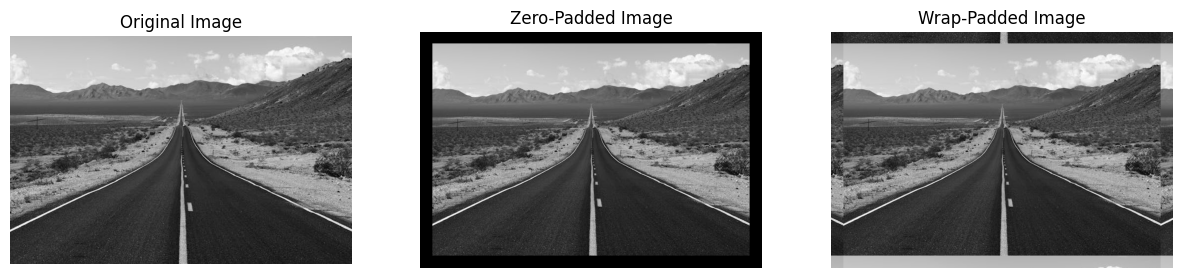

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image (ensure the image 'road' is in the same directory or provide the full path)
image = cv2.imread('road.jpg', cv2.IMREAD_COLOR)

# Check if the image was loaded
if image is None:
    print("Error: Could not load image!")
else:
    # Convert from BGR (OpenCV default) to RGB for correct color display in matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Define the padding size (e.g., pad by 10 pixels on all sides)
    padding_size = 25

    # Apply zero-padding using np.pad
    zero_padded_image = np.pad(image_rgb,
                               ((padding_size, padding_size), (padding_size, padding_size), (0, 0)),
                               mode='constant', constant_values=0)

    # Apply wrap-padding using np.pad (circular padding)
    wrap_padded_image = np.pad(image_rgb,
                               ((padding_size, padding_size), (padding_size, padding_size), (0, 0)),
                               mode='wrap')

    # Display the original, zero-padded, and wrap-padded images side by side
    plt.figure(figsize=(15, 5))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')

    # Zero-padded image
    plt.subplot(1, 3, 2)
    plt.imshow(zero_padded_image)
    plt.title("Zero-Padded Image")
    plt.axis('off')

    # Wrap-padded image
    plt.subplot(1, 3, 3)
    plt.imshow(wrap_padded_image)
    plt.title("Wrap-Padded Image")
    plt.axis('off')

    plt.show()


3.2. The Shawshank Redemption is my favorite movie. However, my TV is too old now and I cannot see things clearly. Can you fix my TV? I left a frame of the movie for you to have a look (shawshank.png). (5 marks)

<a href="https://ibb.co/k15HCXQ"><img src="https://i.ibb.co/M6Z207M/shawshank.png" alt="shawshank" border="0"></a><br /><a target='_blank' href='https://ar.imgbb.com/'></a>

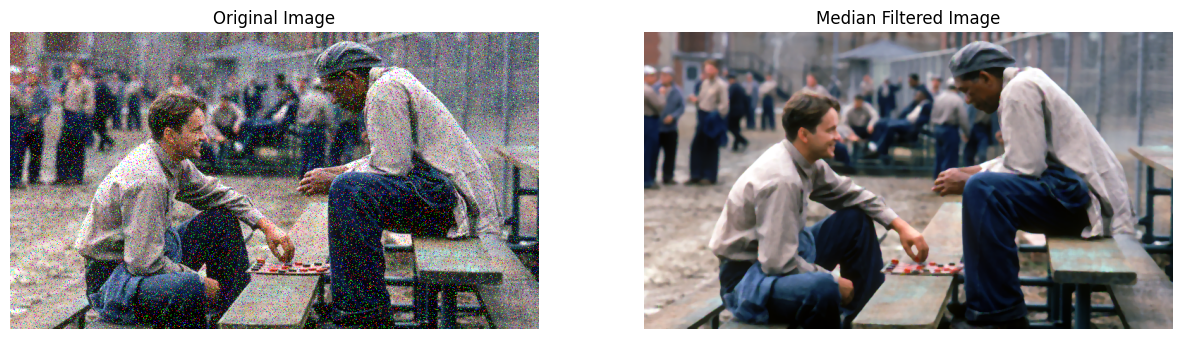

In [ ]:
image = cv2.imread('shawshank.png', cv2.IMREAD_COLOR)

# Check if the image was loaded
if image is None:
    print("Error: Could not load image!")
else:

    median_filtered_image = cv2.medianBlur(image, ksize=5)

    plt.figure(figsize=(15,5))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(median_filtered_image, cv2.COLOR_BGR2RGB))
    plt.title('Median Filtered Image')
    plt.axis('off')

    plt.show()

**3.3.** This TV channel made a horrible mistake (TV.jpg). Could you help them out and fix it? Use box and gaussian filters and compare. (5 marks)

<a href="https://imgbb.com/"><img src="https://i.ibb.co/J5zJ75c/TV.jpg" alt="TV" border="0"></a>

(-0.5, 397.5, 603.5, -0.5)

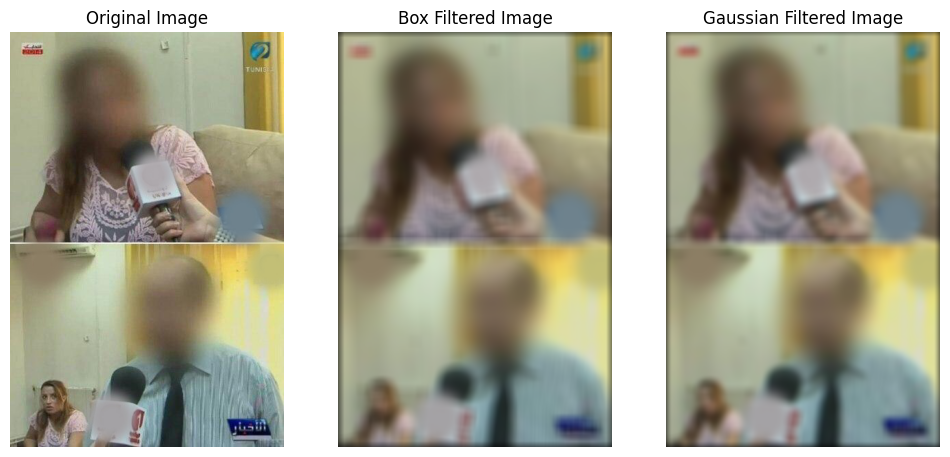

In [ ]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

# Read the image
image = cv2.imread('TV.jpg', cv2.IMREAD_COLOR)
#image = gaussian_noise(image, sigma=55)

# Apply the box filter
box_filtered_image = cv2.boxFilter(image, -1, ksize=(18,18), borderType=cv2.BORDER_CONSTANT)
gaussian_filtered_image = cv2.GaussianBlur(image, ksize=(17,17), sigmaX = 6, sigmaY = 6, borderType=cv2.BORDER_CONSTANT)

# Display the original and smooth filter
plt.figure(figsize=(12, 10))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(box_filtered_image, cv2.COLOR_BGR2RGB))
plt.title('Box Filtered Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(gaussian_filtered_image, cv2.COLOR_BGR2RGB))
plt.title('Gaussian Filtered Image')
plt.axis('off')

Box Filter: Averages all pixels in a fixed window, which can create an overly smooth and somewhat artificial-looking blur. It's faster but may blur edges too much.

Gaussian Blur: Applies a weighted average, resulting in a more refined and smoother blur that maintains edges better. Gaussian blurring is more commonly used in image processing because of its natural blurring effect.

**3.4.** MNIST is a hand-written digits dataset. Sharpen the image obtained above by applying an appropriate kernel and show your results. The variable name of your image is called (img). (1 mark)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Please enter your 5/6 digits AUS ID : 97205


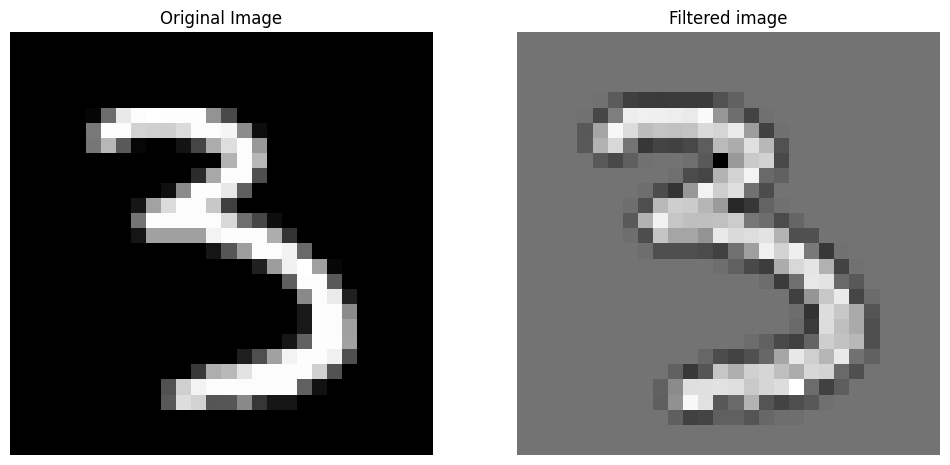

In [2]:
# @title Run the following cell to get the image you need to sharpen
import cv2 as cv
import numpy as np

image = cv.imread('data/images/einstein.jpg', cv.IMREAD_GRAYSCALE)
import tensorflow as tf
import matplotlib.pyplot as plt

mnist = tf.keras.datasets.mnist
(train_images, _), (_, _) = mnist.load_data()

id = input("Please enter your 5/6 digits AUS ID : ")


if len(id) < 5 or id.isdigit() == False:
    print("Please enter a valid AUS ID!")
else:
  img = train_images[(int(id) % len(train_images) - 1)]


  # Define a 3x3 filter or kernel
  f1 = 1/9 * np.array([[0, -1, 0],
                      [-1, 5,-1],
                      [0, -1, 0]])
  # Apply the kernel using convolution
  image = cv.filter2D(src=img, ddepth=cv.CV_32F, kernel=f1, borderType=cv.BORDER_CONSTANT)

  # Display the original and filtered image
  plt.figure(figsize=(12,10))

  plt.subplot(121)
  plt.imshow(img, cmap = 'gray')
  plt.title('Original Image'), plt.axis('off')

  plt.subplot(122)
  plt.imshow(image, cmap = 'gray')
  plt.title('Filtered image'), plt.axis('off')
